# Exercise 8: June 18, 2025

# Solving Differential Equations Using Python's Built in Solver

**Question 1.** Use `solve_ivp` to solve the equation

$\frac{dy}{dt} = \sin{(t)}^2y$,

from $t=0$ to $t=20$. Use different initial values of $y_0 = 1, 5, 10$.  

The exact solution is:

$y=y_0e^{(\frac{1}{2}[t-\sin{(t)}\cos{(t)}])}$

Plot your numerical solutions and calculate the percent error for them.

In [16]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def p_error(model, exact):
  error = (abs((model-exact)/exact)*100)
  return error

Error y_0(1):  0.3992672711682906
Error y_0(5):  0.39926727116829497
Error y_0(10):  0.39926727116829497


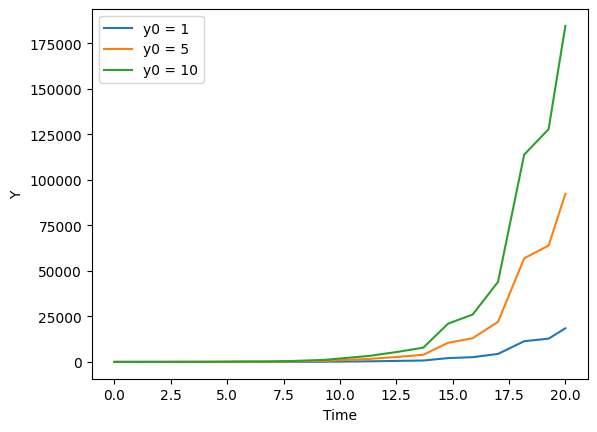

In [18]:
def d_function(t,y):
  return ((np.sin(t)**2)*y)

y0 = np.array([1,5,10])
t_span = np.array([0,20])
sol = sp.integrate.solve_ivp(d_function, t_span, y0)
t_sol = sol.t
y_sol = sol.y
y_exact1 = (y0[0])*(np.exp((1/2)*(t_sol-np.sin(t_sol)*np.cos(t_sol))))
y_exact2 = (y0[1])*(np.exp((1/2)*(t_sol-np.sin(t_sol)*np.cos(t_sol))))
y_exact3 = (y0[2])*(np.exp((1/2)*(t_sol-np.sin(t_sol)*np.cos(t_sol))))

error1 = []
for i in range(len(y_sol[0])):
  error1.append(p_error(y_sol[0][i], y_exact1[i]))
print("Error y_0(1): ", (np.average(error1)))

error2 = []
for i in range(len(y_sol[1])):
  error2.append(p_error(y_sol[1][i], y_exact2[i]))
print("Error y_0(5): ", (np.average(error2)))

error3 = []
for i in range(len(y_sol[2])):
  error3.append(p_error(y_sol[2][i], y_exact3[i]))
print("Error y_0(10): ", (np.average(error3)))


plt.plot(t_sol,y_sol[0], t_sol,y_sol[1], t_sol,y_sol[2])
plt.legend(["y0 = 1", "y0 = 5", "y0 = 10"])
plt.xlabel("Time")
plt.ylabel("Y")

plt.show()

**Question 2.** We will calculate the rate of heat production in the mantle back through Earth's history using the exponential growth equation. In Earth's mantle there are 4 major elements that produce heat by radioactive decay: $^{232}$Th, $^{235}$U, $^{238}$U, and $^{40}$K. Taking the concentration, $C$, of each of these elements in the mantle today, we can calculate them back in time by solving the equation:

$\frac{dC}{dt} = \frac{\ln{(2)}}{\tau_{1/2}} C$

where $\ln$ is the natural logarithm and $\tau_{1/2}$ is the half-life of the radioactive element.

Solve this equation for the 4 major radioactive elements listed above going back in time 4.5 billion years, when Earth formed (so $t$ will go from $0$, representing the present day, to $t=4.5 \times 10^9$ years, representing when Earth formed). The 4 elements all have different initial concentrations, $C_0$ (which is the initial value for our numerical solutions), and half-lives, $\tau_{1/2}$.

$^{232}$Th: $C_0 = 8.3 \times 10^{-8}$, $\tau_{1/2} = 1.4 \times 10^{10}$ years

$^{235}$U: $C_0 = 1.584 \times 10^{-10} \times 10^{-8}$, $\tau_{1/2} = 7.04 \times 10^{8}$ years

$^{238}$U: $C_0 = 2.18 \times 10^{-8} \times 10^{-8}$, $\tau_{1/2} = 4.46 \times 10^{9}$ years

$^{40}$K: $C_0 = 3.05 \times 10^{-8} \times 10^{-8}$, $\tau_{1/2} = 1.26 \times 10^{9}$ years

The units for concentration, $C$, are kg/kg; that is kg of the radioactive element per 1 kg of mantle rock.

Plot your results for the concentrations of each of the 4 elements back to the time of Earth's formation on the same graph. Include a legend and axis labels, and be careful to keep units consistent.

So you can check your answers, the concentrations at $t=4.5$ billion years should be: `1.0371408356366105e-07 1.330310610079081e-08 4.387188724010296e-08 3.6258262501065843e-07` for $^{232}$Th, $^{235}$U, $^{238}$U, and $^{40}$K, respectively.



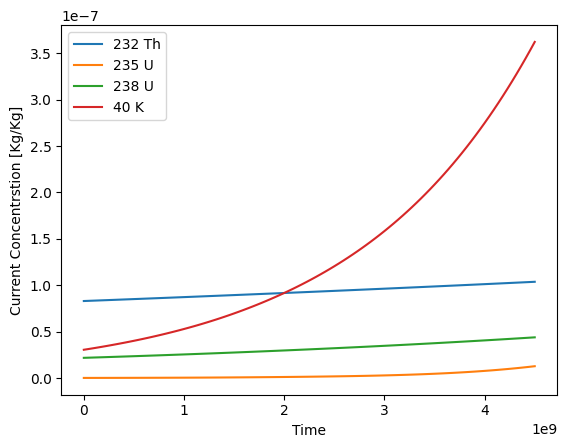

In [19]:
def con_fun(t, con, h_life):
  return ((np.log(2)/h_life)*(con))

t_span = np.array([0, 4.5*10**9])
t_pts = np.linspace(t_span[0], t_span[1], 100)
C0 = np.array([8.3*10**(-8)])
h_span = np.array([1.4*10**10])

sol = sp.integrate.solve_ivp(con_fun, t_span, C0, atol=1e-6, rtol=1e-6, args=(h_span), t_eval=t_pts)
t_sol1 = sol.t
con_sol1 = sol.y


C0 = np.array([1.584*10**(-10)])
h_span = np.array([7.04*10**8])

sol = sp.integrate.solve_ivp(con_fun, t_span, C0, atol=1e-6, rtol=1e-6, args=(h_span), t_eval=t_pts)
t_sol2 = sol.t
con_sol2 = sol.y


C0 = np.array([2.18*10**(-8)])
h_span = np.array([4.46*10**9])

sol = sp.integrate.solve_ivp(con_fun, t_span, C0, atol=1e-6, rtol=1e-6, args=(h_span), t_eval=t_pts)
t_sol3 = sol.t
con_sol3 = sol.y


C0 = np.array([3.05*10**(-8)])
h_span = np.array([1.26*10**9])

sol = sp.integrate.solve_ivp(con_fun, t_span, C0, atol=1e-6, rtol=1e-6, args=(h_span), t_eval=t_pts)
t_sol4 = sol.t
con_sol4 = sol.y


plt.plot(t_sol1,con_sol1[0], t_sol2,con_sol2[0], t_sol3,con_sol3[0], t_sol4,con_sol4[0])
plt.legend(["232 Th", "235 U", "238 U", "40 K"])
plt.xlabel("Time")
plt.ylabel("Current Concentrstion [Kg/Kg]")

plt.show()

**Question 3.** Now we will convert these concentrations into a rate of heat production in W/kg. The 4 radioactive elements producing heat in Earth's interior each have an intrinsic heat production rate as they decay, which I'll call $h$. This gives the energy per unit time generated (Watts) per kilogram of radioactive element:

$^{232}$Th: $h= 2.63 \times 10^{-5}$ W/kg

$^{235}$U: $h= 5.68 \times 10^{-4}$ W/kg

$^{238}$U: $h= 9.51 \times 10^{-5}$ W/kg

$^{40}$K: $h= 2.85 \times 10^{-5}$ W/kg

Multiplying these values of $h$ by each of the concentrations, $C$, we calculated in the previous question will give the heat production rate from each radioactive element per 1 kg of mantle rock. Calculate and plot that.

So you can check your answers, the heat production rates in W/kg at $t=4.5$ billion years should be: `2.7276803977242854e-12 7.556164265249181e-12 4.172216476533792e-12 1.0333604812803765e-11` for $^{232}$Th, $^{235}$U, $^{238}$U, and $^{40}$K, respectively.

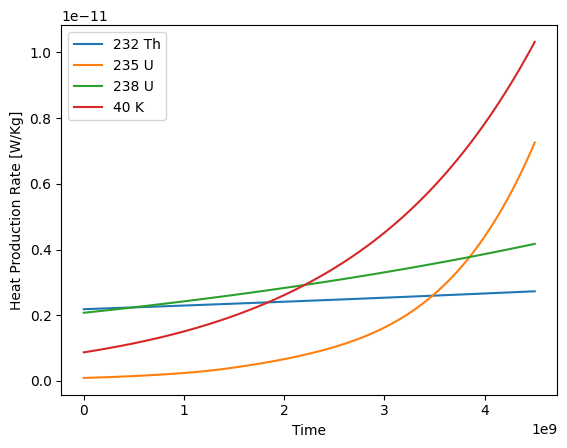

In [20]:
Th_hp_rate = (con_sol1[0])*(2.63*10**(-5))
U1_hp_rate = (con_sol2[0])*(5.68*10**(-4))
U2_hp_rate = (con_sol3[0])*(9.51*10**(-5))
K_hp_rate = (con_sol4[0])*(2.85*10**(-5))

plt.plot(t_sol1,Th_hp_rate, t_sol2,U1_hp_rate, t_sol3,U2_hp_rate, t_sol4,K_hp_rate)
plt.legend(["232 Th", "235 U", "238 U", "40 K"])
plt.xlabel("Time")
plt.ylabel("Heat Production Rate [W/Kg]")

plt.show()

**Question 4.** Now multiply the heat production rates you calculed in Question 3 by the mass of the mantle, which is $4.04 \times 10^{24}$ kg. This will give the total heat production in Watts in the mantle over time from each of the 4 radioactive elements.

Plot this result for each element.

$10^{12}$ watts is called a terrawatt, or TW for short. For context, humanity's rate of energy usage is about 20 TW.

So you can check your answers, the heat production rates in TW at $t=4.5$ billion years should be: `11.019828806806112 30.526903631606693 16.855754565196516 41.74776344372721` for $^{232}$Th, $^{235}$U, $^{238}$U, and $^{40}$K, respectively.

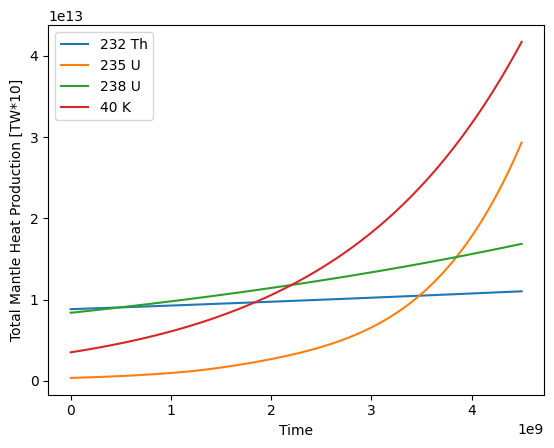

In [21]:
Th_total_hp = (Th_hp_rate)*(4.04*10**24)
U1_total_hp = (U1_hp_rate)*(4.04*10**24)
U2_total_hp = (U2_hp_rate)*(4.04*10**24)
K_total_hp = (K_hp_rate)*(4.04*10**24)

plt.plot(t_sol1,Th_total_hp, t_sol2,U1_total_hp, t_sol3,U2_total_hp, t_sol4,K_total_hp)
plt.legend(["232 Th", "235 U", "238 U", "40 K"])
plt.xlabel("Time")
plt.ylabel("Total Mantle Heat Production [TW*10]")

plt.show()

# Modeling Earth's Thermal Evolution

We will work with the thermal evolution model introduced in the lecture notebook for the last few questions:

$\frac{dT}{dt} = \frac{H}{c_p} - \frac{A F_s}{M c_p}$

where $M$ is the mass of the mantle, $c_p$ is the specific heat of the mantle, $T$ is the mantle temperature, $t$ is time, $H$ is the total heat production rate per unit mass from radioactive elements, $A$ is the surface area of the Earth, and $F_s$ is the heat flux out of the mantle.

The heat flux, $F_s$, is given by:

$F_s = ck \frac{(T-T_s)^{4/3}}{d} \left( \frac{\rho g \alpha d^3}{\kappa \mu} \right)^{1/3}$

where $c$ is a constant, $k$ is the thermal conductivity of the Earth, $T_s$ is the surface temperature, $d$ is the thickness of the mantle, $\rho$ is the average density of the mantle, $g$ is acceleration due to gravity, $\alpha$ is the thermal expansion coefficient, $\kappa$ is the thermal diffusivity, and $\mu$ is the viscosity. I gave numbers for these parameters in the lecture notebook; use the same numbers unless otherwise stated for the following questions.

Two additional effects we'll include in the questions below is that the heat production rate decays over time following the equation:

$H = H_0 \exp{\left(- \frac{t}{\tau} \right)} $

where $H_0$ is the heat production rate at time $t=0$, which corresponds to the time of Earth's formation (time will run forward from 0 to $t=4.5$ billion years, which is today, in the following questions) and $\tau$ is a decay constant.

And in question 5 you will include the effect that viscosity, $\mu$, depdends on the temperature of the mantle, $T$.



**Question 5.** First, we will add an important effect to the model. That is that the viscosity of the mantle depends strongly on mantle temperature. When temperature is high viscosity is lower, and this makes mantle convection more vigorous and heat flux higher. When temperature is low viscosity is larger and convection is slower.

Viscosity follows the equation:

$\mu = \mu_{ref} \exp{\left(\frac{E_v}{R} \left(\frac{1}{T}-\frac{1}{T_{ref}} \right) \right)}$

where $\mu_{ref} = 10^{21}$ Pa s (Pascal seconds) is the refernece viscosity, defined as the present day mantle viscosity. $E_v = 350000$ J/mol is the activation energy, $R=8.314$ is the gas constant, $T_{ref} = 1623$ K.

Include the viscosity equation here in the simple model I gave in the lecture notebook, where heat production is constant and equal to $H_0 = 20$ TW. Solve the model over a time span from $t=0$ to $t=5$ Gyrs, and use three initial temperatures of 2000 K, 1000 K, and 500 K. Plot the result.  

In [22]:
c=0.12
k=5 # units are W/m/K
d=2890000 # thicknesss of the mantle in m
Ts=273 # Surface temperature in degrees kelvin
rho=4500 # average density of the mantle in kg/m^3
g=9.8 # acceleration from gravity in m/s^2
alpha=3e-5 # thermal expansion coefficient in units of 1/K
kappa=1e-6 # thermal diffusion coefficient in m^2/s

M=4.04e24 # mass of the mantle in kilograms
A=4*np.pi*6371000**2 # surface area of Earth in meters
cp=1250 # specific heat, units are J kg^-1 K^-1

In [23]:
v_ref = 10**21
Ev = 3.5*10**5
R = 8.314
T_ref = 1623
H0 = (20*10**12)/M

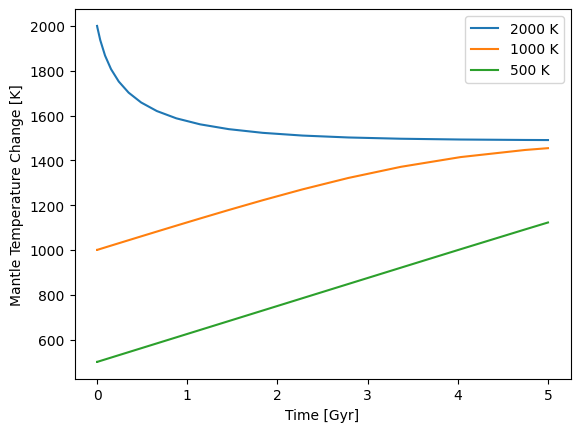

In [24]:
def visc(t,T,H_0):
  Fs=c*k*(T-Ts)**(4/3)*(1/d)*((rho*g*alpha*d**3)/(kappa*(v_ref*np.exp((Ev/R)*((1/T)-(1/T_ref))))))**(1/3)
  return (H_0/cp - A*Fs/(M*cp))

t_span = np.array([0,5e9*3600*24*365])
T0 = np.array([2000, 1000, 500])

sol = sp.integrate.solve_ivp(visc, t_span, T0, atol=1e-6, rtol=1e-6, args=(H0,))
t_sol = sol.t
T_sol = sol.y

plt.plot(t_sol/(1e9*3600*24*365),T_sol[0], t_sol/(1e9*3600*24*365),T_sol[1], t_sol/(1e9*3600*24*365),T_sol[2])
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature Change [K]")
plt.legend(["2000 K","1000 K","500 K"])

plt.show()

What are the differences you see compared to the example in the lecture notebook where viscosity was constant (did not depend on temperature)? What causes these?

**The lines for 2000 K and 1000 K still begin to converge, but at a higher temperature, making the 2000 K line more compact and giving the 1000 K line more curvature. Additionally, the 500 K line appears linear and seems to converge at a later time than in the previous model.**

**Question 6.** Now we will set the viscosity back to constant, which you can do by setting $E_v = 0$, but include the decay of the heat producing elements. The heat produciton equation will be:

$H = H_0 \exp{\left(- \frac{t}{\tau} \right)} $ .

Use $H_0 = 2 \times 10^{-11}$ W/kg and $\tau = 2.9$ Gyrs. Solve for initial temperatures of 2000 K, 1500 K, and 1300 K over a timespan from 0 to 10 Gyrs. Plot the result.

In [25]:
Ev = 0
H0 = 2*10**(-11)
decay = 2.9e9*35*24*60*60

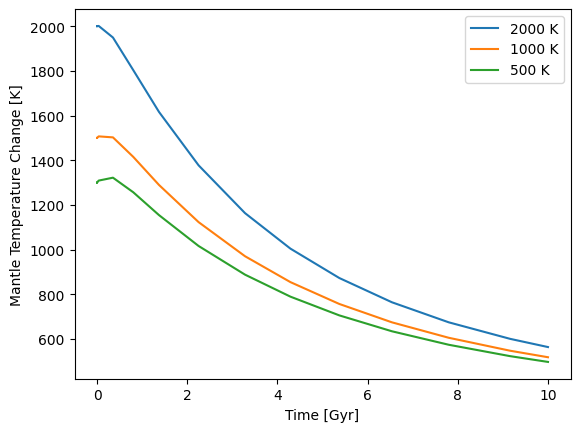

In [26]:
def visc(t,T,H_0):
  Fs=c*k*(T-Ts)**(4/3)*(1/d)*((rho*g*alpha*d**3)/(kappa*(v_ref*np.exp((Ev/R)*((1/T)-(1/T_ref))))))**(1/3)
  return ((H0*np.exp(-t/decay))/cp - A*Fs/(M*cp))

t_span = np.array([0,10e9*3600*24*365])
T0 = np.array([2000, 1500, 1300])

sol = sp.integrate.solve_ivp(visc, t_span, T0, atol=1e-6, rtol=1e-6, args=(H0,))
t_sol = sol.t
T_sol = sol.y

plt.plot(t_sol/(1e9*3600*24*365),T_sol[0], t_sol/(1e9*3600*24*365),T_sol[1], t_sol/(1e9*3600*24*365),T_sol[2])
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature Change [K]")
plt.legend(["2000 K","1000 K","500 K"])

plt.show()

What changes do you see compared to question 5 and what causes these?

**This model seems to reflect exponential decay, as the three lines converge with a decreasing slope. This is the result of the heat flux increasing because Ev = 0 causes the denominator of (rho*g*alpha*d^3)/(kappa*mu)^(1/3) to decrease, as mu would equal 0. Also, the heat production rate will be decreased as time increases because it will create a larger negative number for the exponent, meaning the denominator is increasing while the numerator is constant. Thus, in the equation for temperature change (dT/dt), the positive fraction (left) will be decreasing and the negative fraction, the fraction being subtracted (right), will be increasing. Therefore, the change in temperature is decreasing exponentially.**

**Question 7.** For this last question you will include both temperature dependent viscosity, like you did in question 5, and decaying heat production, like you did in question 6. Use the initial temperatures of 2000 K, 1500 K, and 1300 K, and plot the result from 0 to 10 Gyrs.

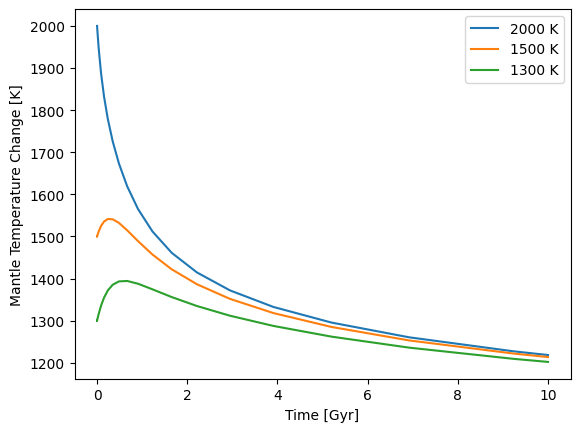

In [27]:
v_ref = 10**21
Ev = 3.5*10**5
R = 8.314
T_ref = 1623
H0 = 2*10**(-11)
decay = 2.9e9*35*24*60*60

def visc(t,T,H_0):
  Fs=c*k*(T-Ts)**(4/3)*(1/d)*((rho*g*alpha*d**3)/(kappa*(v_ref*np.exp((Ev/R)*((1/T)-(1/T_ref))))))**(1/3)
  return ((H_0*np.exp(-t/decay))/cp - A*Fs/(M*cp))

t_span = np.array([0,10e9*365*3600*24])
T0 = np.array([2000, 1500, 1300])

sol = sp.integrate.solve_ivp(visc, t_span, T0, atol=1e-6, rtol=1e-6, args=(H0,))
t_sol = sol.t
T_sol = sol.y

plt.plot(t_sol/(1e9*3600*24*365),T_sol[0], t_sol/(1e9*3600*24*365),T_sol[1], t_sol/(1e9*3600*24*365),T_sol[2])
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature Change [K]")
plt.legend(["2000 K","1500 K","1300 K"])

plt.show()

Compare and contrast this result with your answers to questions 5 & 6, and explain what you think causes the differences.

**While both models show the lines of the three different temperatures converging, not all temperature for the temperature dependent viscosity are decreasing in value. This is because the initial values of the temperature for 1300 K and 1500K are low enough, so that the values of the viscosity and heat flux are not decreasing exponentially. The decay model has each value decreasing at different rates, because the viscosity is not temperature dependent. So, the lower temperatures for this model will only start at lower temperatures and have a less steep slope.**